<a href="https://colab.research.google.com/github/suwabe-j/practice-project/blob/main/chapter8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Index([76], dtype='int64')
Index([76], dtype='int64')


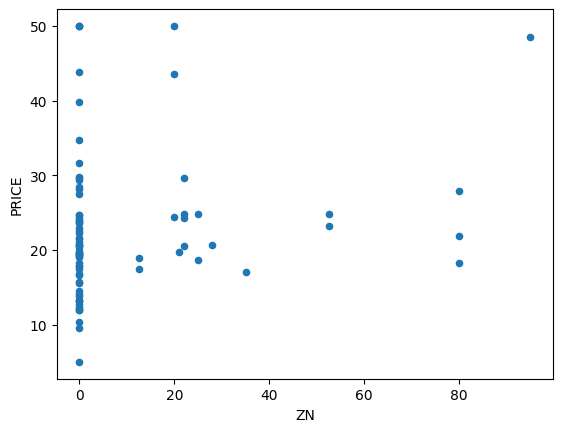

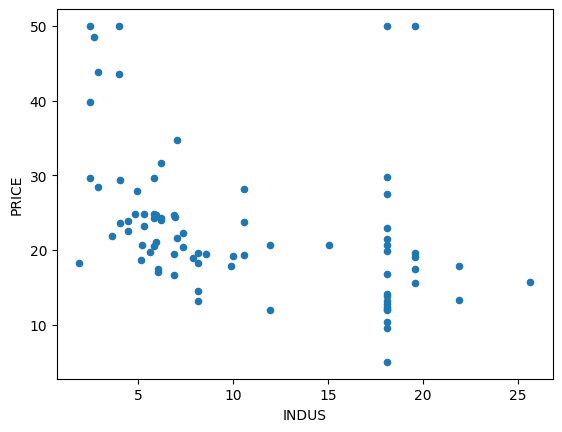

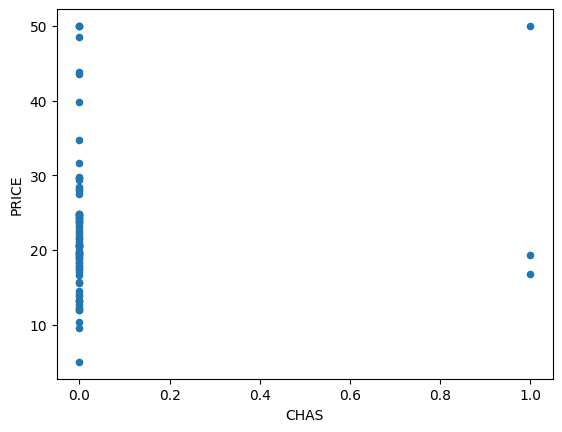

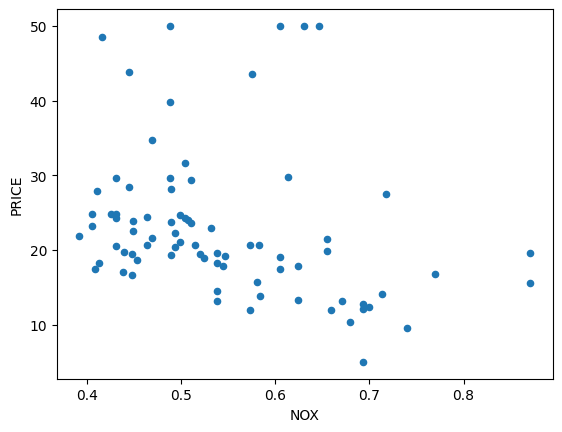

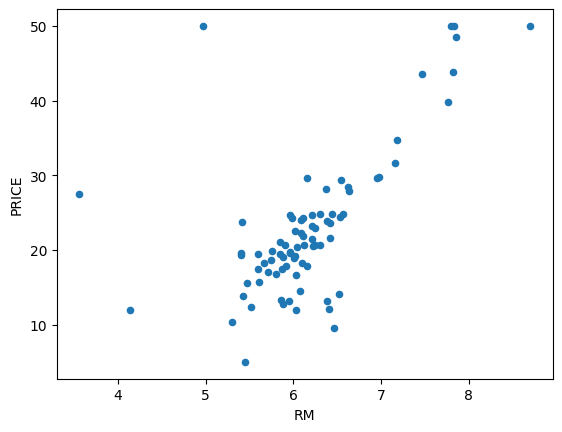

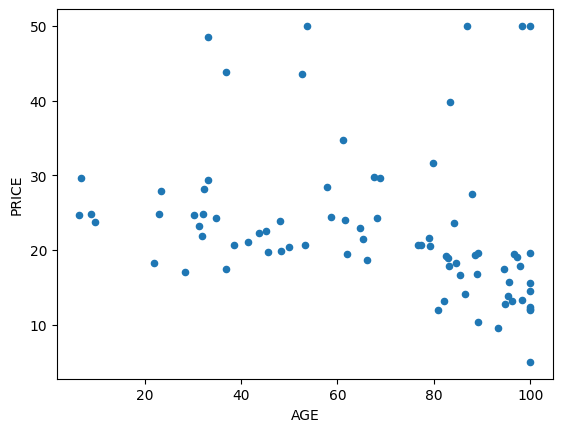

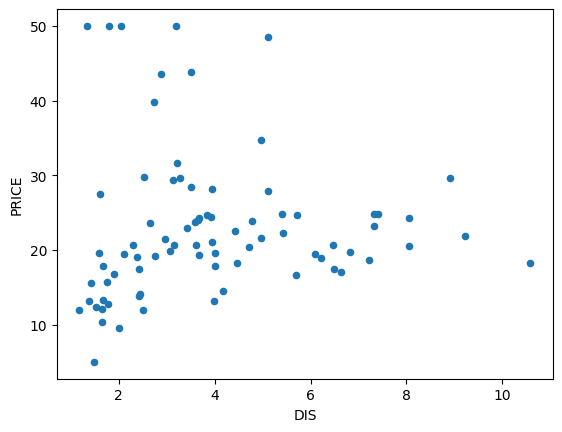

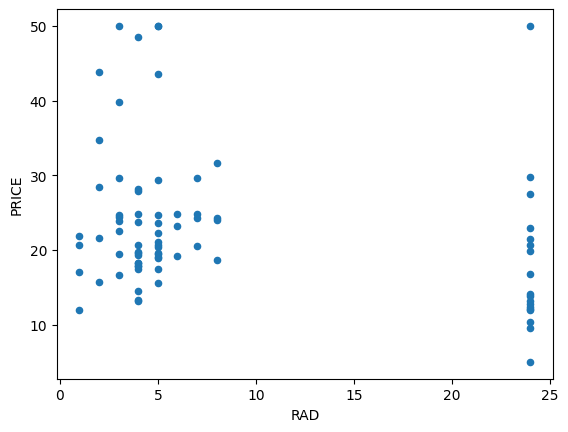

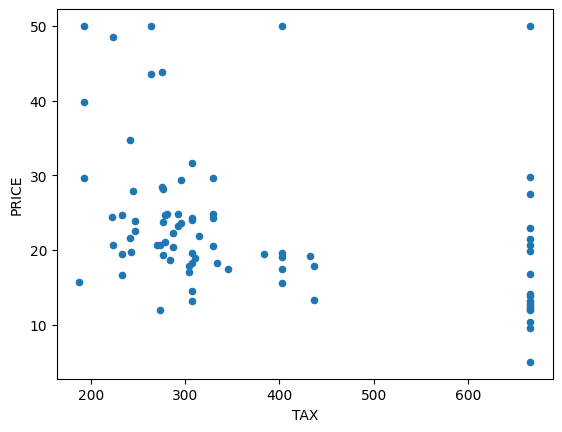

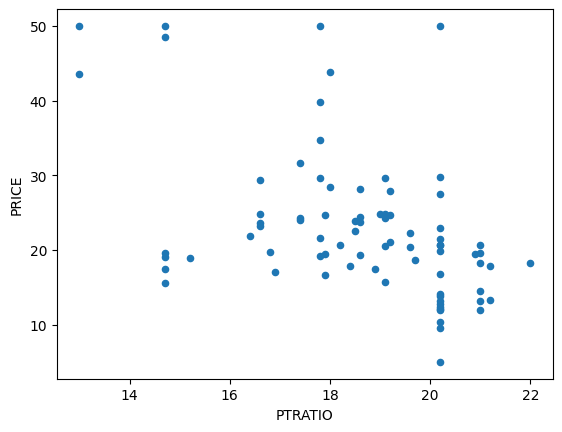

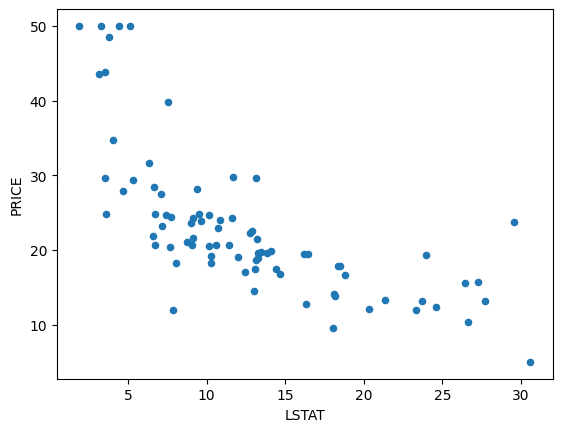

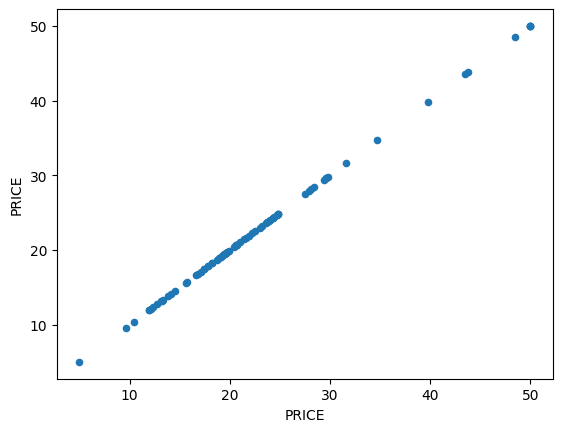

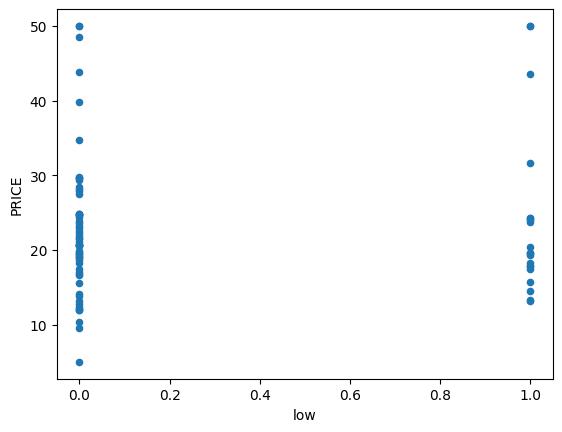

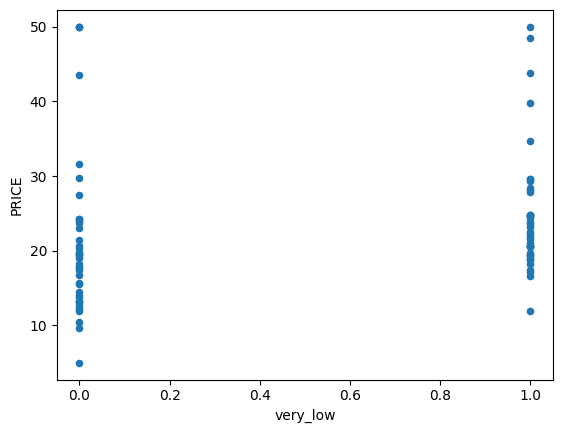

In [5]:
from numpy.random.mtrand import RandomState
# pandasのインポート
import pandas as pd
# 回帰曲線の機械学習を行いたいのでインポート
from sklearn.linear_model import LinearRegression
# テストデータと検証データを分割したいのでインポート
from sklearn.model_selection import train_test_split

# csvファイルをこちらで使えるように落とし込み、内容を確認
df = pd.read_csv("Boston.csv")
df.head(3)

# 確認したらCRIMEが文字で、分析に使用できないのでダニー数変化させて、分析に使用できるようにする
df["CRIME"].value_counts()

# ３種類だと確認できたので、ダミー数変化で２個に分けて合体させる
crime = pd.get_dummies(df["CRIME"], drop_first=True, dtype=int)
# 行結合で、ダミー数変化させたものと、元々のデータと合体させる
df2 = pd.concat([df, crime],axis=1)
# 合体させた表で元々文字データだったものは不要になるので、削除する（列参照なので、axisは１）
df2 = df2.drop("CRIME", axis=1)
# 確認する
df2.head(2)
# ここから訓練データ＆検証データ、テストデータの２つに分ける
# 先に行ってしまうと、分割した際に３種類がバランスよく別れるとは限らないので先にダミー数変化させる
train_val, test= train_test_split(df2, test_size=0.2, random_state=0)
# 訓練＆検証データの欠損値がないかどうか確認する
train_val.isnull().sum()
# NOX列に欠損値があるので、その欠損値を平均値で穴埋めする
train_val_mean = train_val.mean()
train_val2 = train_val.fillna(train_val_mean)
# ハズレ値がないかどうか散布図を作成して確認する（住居価格を予想したいので、正解データは価格のPRICE）
colume = train_val2.columns
for name in colume:
  train_val.plot(kind="scatter", x=name, y="PRICE")
# INDUS, NOX, RM, PTRATIO, LSTATの５種類が特徴量として良さそうと、散布図の分散や相関具合から判断
# RMの明らかなハズレ値のインデックスを確認する
out_rm_index = train_val2[(train_val2["RM"]<6)&(train_val2["PRICE"]>40)].index
# PTRATIO列の明らかなハズレ値のインデックスを確認する
out_ptratio_index = train_val2[(train_val2["PTRATIO"]>18)&(train_val2["PRICE"]>40)].index
# 同じ行の可能性もあるので、一回インデックスを確認する
print(out_rm_index)
print(out_ptratio_index)
# どちらも76行目だと判明したので７６行目を削除したVerを作成する
train_val3 = train_val2.drop([76], axis=0)
# 特徴量として使用するカラムだけをデータから抽出する
colums = ["INDUS", "NOX", "RM", "PTRATIO", "LSTAT", "PRICE"]
train_val4 = train_val3[colums]
train_val4.head(3)
# 特徴量が多いので、もう少し絞りたい。相関係数を確認してより相関が強いものを残す
# シリーズの各セルにabs関数を使用して、絶対値（abs）に変更
# 分かりやすく昇順に並べる
train_val4.corr()["PRICE"].map(abs).sort_values(ascending=False)
# 使用する相関の強いカラム（RM,LSTAT,PTRATIO）が特定できたので、そのカラムで実験していく
col = ["RM", "LSTAT", "PTRATIO"]
x = train_val4[col]
t = train_val4[["PRICE"]]
x_train, x_val, y_train, y_val = train_test_split(x, t, test_size=0.2, random_state=0)
# データの値の強弱が数値によって異なるので、標準化させて一定にさせる
# StandardScalerモデルを作成して、平均値や標準偏差の情報を格納させる
from sklearn.preprocessing import StandardScaler
sc_model_x = StandardScaler()
# 情報を格納させるためにfitting
sc_model_x.fit(x_train)
# 標準化
sc_x = sc_model_x.transform(x_train)
# 実際に標準化できているかどうか（＝平均値が０かどうか）を確認する。
# array型だと見にくいので、データフレーム型へ
tmp_df = pd.DataFrame(sc_x, columns=x_train.columns)
# 平均値と標準偏差の確認
tmp_df.mean()
tmp_df.std()
# 検証データも標準化させる（金額の差は小さいので、一般的にはしないのが良い。学習のため実施）
sc_model_y = StandardScaler()
sc_model_y.fit(y_train)
sc_y = sc_model_y.transform(y_train)
# 重回帰モデルの作成〜決定係数の確認
model = LinearRegression()
model.fit(sc_x, sc_y)
sc_x_val = sc_model_x.transform(x_val)
sc_y_val = sc_model_y.transform(y_val)
model.score(sc_x_val, sc_y_val)
# 決定係数が0.7くらいだったので、0.8あたりを目指したい
# 特徴量と正解データを引数にして、訓練データと検証データでの決定係数を出力するlearn関数を作成する（今までの流れ）
def learn(x,t):
  x_train, x_val, y_train, y_val=train_test_split(x, t, test_size=0.2, random_state=0)
  sc_model_x = StandardScaler()
  sc_model_y = StandardScaler()
  sc_x_train = sc_model_x.fit_transform(x_train)
  sc_y_train = sc_model_y.fit_transform(y_train)
  linear_model = LinearRegression()
  linear_model.fit(sc_x_train, sc_y_train)

  sc_x_val = sc_model_x.transform(x_val)
  sc_y_val = sc_model_y.transform(y_val)

  train_score = linear_model.score(sc_x_train, sc_y_train)
  val_score = linear_model.score(sc_x_val, sc_y_val)

  return train_score, val_score

# 作成したlearn関数を試しに実行してみる（動作確認）
x = train_val3.loc[ : ,["RM", "LSTAT", "PTRATIO"]]
t = train_val3[["PRICE"]]
# print(learn(x, t))←動作確認の部分はコメントアウトする
# 実行は成功したが、決定係数が目標の0.8に届かないので特徴量エンジニアリングを行う
x["RM2"] = x["RM"]**2
x["PTRATIO2"] = x["PTRATIO"]**2
x["LSTAT2"] = x["LSTAT"]**2
# print(learn(x, t))←コメントアウト
# まだ0.87にはいかないので、交差作用特徴量（特徴量同士を掛け算したもの）を追加する
x["RM * LSTAT"] = x["RM"] * x["LSTAT"]
# print(learn(x, t))←コメントアウト
# 検証データで0.87が完成したので、この方法で確定とする
# ２乗したものと、交差作用させたものがxに増えたので、もう一度標準化させる
sc_model_x2 = StandardScaler()
sc_x = sc_model_x2.fit_transform(x)

sc_model_y2 = StandardScaler()
sc_y = sc_model_y2.fit_transform(t)

model = LinearRegression()
model.fit(sc_x, sc_y)

# まったく同じ流れでテストデータの前処理を行っていく
test2 = test.fillna(train_val.mean())
# 特徴量と正解データも同様
x_test = test2.loc[ : , ["RM", "LSTAT", "PTRATIO"]]
y_test = test2[["PRICE"]]
# 特徴量エンジニアリングも同様
x_test["RM2"] = x_test["RM"]**2
x_test["PTRATIO2"] = x_test["PTRATIO"]**2
x_test["LSTAT2"] = x_test["LSTAT"]**2
x_test["RM * LSTAT"] = x_test["RM"] * x_test["LSTAT"]

# データリークを避けるために訓練＆検証データの平均値で穴埋めする
sc_x_test = sc_model_x2.transform(x_test)
sc_y_test = sc_model_y2.transform(y_test)
# 決定係数（どこまで３つの特徴量で正解データを判定できるか）の計算
model.score(sc_x_test, sc_y_test)

# モデルを保存する
import pickle
# boston.pklを書き込み形式で開き、変数fを経由して作成したmodelの情報を書き込む
with open("boston.pkl", "wb") as f:
  pickle.dump(model,f)
# 訓練データの平均値や標準偏差のデータが入っているモデルを保存（x）
with open("boston_scx.pkl","wb") as f:
  pickle.dump(sc_model_x2,f)
# 訓練データの平均値や標準偏差のデータが入っているモデルを保存（y）
with open("boston_scy.pkl","wb") as f:
  pickle.dump(sc_model_y2,f)
